In [1]:
import pandas as pd

df = pd.read_csv("data/business_data.csv")

df.head()

,Order Date,Sales,Profit,Category,Sub-Category,Region,Segment,Quantity,Discount
0,2024-03-12,4003.06,347.01,Office Supplies,Binders,East,Home Office,3,0.03
1,2025-10-25,4344.26,739.49,Office Supplies,Storage,West,Consumer,2,0.22
2,2024-10-03,1140.46,98.50,Furniture,Chairs,South,Corporate,6,0.00
3,2025-11-12,1527.02,263.21,Technology,Machines,West,Corporate,3,0.11
4,2024-01-21,327.61,56.19,Technology,Phones,Central,Corporate,4,0.28


In [2]:
df.info()

df.isnull().sum()

df['Order Date'] = pd.to_datetime(df['Order Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    1000 non-null   object 
 1   Sales         1000 non-null   float64
 2   Profit        1000 non-null   float64
 3   Category      1000 non-null   object 
 4   Sub-Category  1000 non-null   object 
 5   Region        1000 non-null   object 
 6   Segment       1000 non-null   object 
 7   Quantity      1000 non-null   int64  
 8   Discount      1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [4]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')

In [5]:
total_sales = df['Sales'].sum()
print(total_sales)

2574098.65


In [6]:
total_profit = df['Profit'].sum()

In [7]:
avg_discount = df['Discount'].mean()

In [8]:
total_quantity = df['Quantity'].sum()

<Axes: xlabel='Month_Name'>

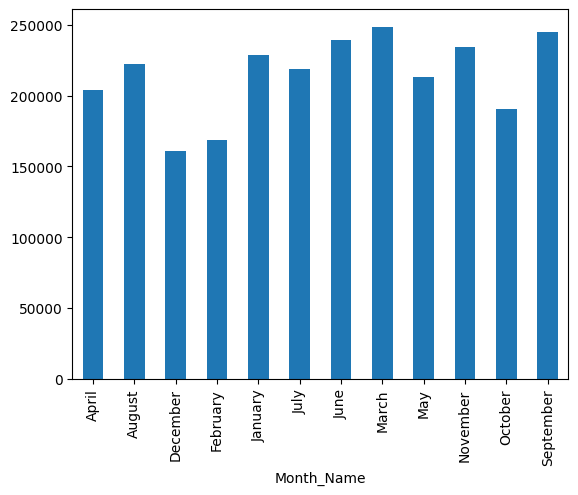

In [9]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales.plot(kind='bar')

<Axes: ylabel='Sales'>

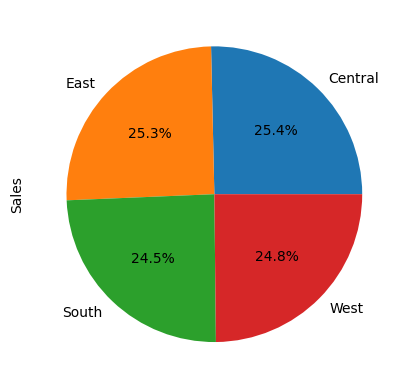

In [10]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Category'>

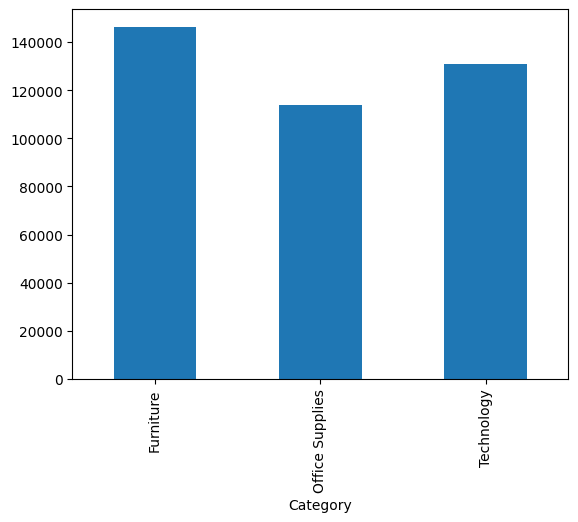

In [11]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['Sales','Quantity','Discount']]
y = df['Profit']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print(r2_score(y_test,pred))

0.5317005986950147


In [14]:
import joblib

joblib.dump(model,'model.pkl')

['model.pkl']

In [18]:
import os

os.listdir()

['.ipynb_checkpoints', 'AI_BI_Analysis.ipynb', 'Data', 'model.pkl', 'Notebook']

In [19]:
os.listdir("Data")

['business_data.csv']